# ML Prediction Pipeline — Notebook 03: Modeling

**Project:** Dubai Residential Property Price Prediction
**Notebook:** 03 — Feature Engineering, Baseline, and Model Comparison
**Author:** Faiha
**Date:** 2026-08-01
**Description:** Engineers features from `data/processed/clean_secondary_sales.csv`, builds a leakage-safe preprocessing pipeline, establishes a baseline, trains and compares three regression models, tunes the best one, and persists it for reuse.

## 1. Introduction and Objectives

**Goal:** predict `price_usd` — the listed sale price of a Dubai secondary-market property — from its physical characteristics, location, and listing attributes.

**Why regression, not classification:** price is a continuous quantity. Binning it into categories (e.g. "cheap / mid / expensive") would discard information and require an arbitrary threshold decision. Regression respects the natural structure of the target and gives richer evaluation: a statement like "the model predicts within ±\$45,000 on average" is directly interpretable by a buyer, seller, or agent in a way a classification accuracy score is not.

**Questions this notebook answers:**
1. Which engineered features actually improve price prediction over the raw columns?
2. How much better are the trained ML models than a naive baseline (always predict    the average price)?
3. Which model generalizes best — i.e. has the smallest train/test performance gap,    not just the best raw score?
4. What factors influence the best model's predictions the most?

**Currency:** per `docs/decisions.md` (decision 0001), the target stays in **USD** throughout this notebook. No AED conversion happens here.


## 2. Load Processed Dataset

We load **only** the cleaned output of `01_data_cleaning.ipynb` — never the raw file. No feature engineering, encoding, or scaling has been applied yet.


In [1]:
# --- Imports (all together, per project convention) ---
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, RandomizedSearchCV, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBRegressor

sys.path.append(str(Path("..").resolve()))

from src.evaluate import (
    build_comparison_table,
    calculate_metrics,
    plot_actual_vs_predicted,
    plot_error_distribution,
    plot_feature_importance,
    plot_residuals,
)
from src.feature_engineering import LocationTierEncoder, engineer_static_features

warnings.filterwarnings("ignore", category=UserWarning)


In [2]:
# --- Configuration ---
RANDOM_STATE = 42
TEST_SIZE = 0.2
N_CV_FOLDS = 5

DATA_PATH = Path("../data/processed/clean_secondary_sales.csv")
IMAGES_DIR = Path("../images")
MODELS_DIR = Path("../models")

PRICE_LABEL = "Price (USD)"

pd.set_option("display.max_columns", 40)
plt.rcParams["figure.dpi"] = 100


In [3]:
df = pd.read_csv(DATA_PATH)
df["date_listed"] = pd.to_datetime(df["date_listed"])

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()


Shape: 50,000 rows x 29 columns


,id,date_listed,community,zone,is_freehold,lat,lon,property_category,property_type,bedrooms,area_sqft,area_m2,floor,total_floors,year_built,view,furnishing,condition,parking_spaces,chiller_included,metro_station,metro_line,metro_distance_min,metro_distance_type,to_burj_khalifa_km,price_usd,price_per_sqft_usd,price_per_m2_usd,mortgage_rate_at_listing
0,S000001,2024-11-23,DIFC,DIFC,True,25.21053,55.29453,apartment,4BR_penthouse,4,3658,339.9,11.0,20.0,2021,burj_khalifa,unfurnished,vacant_on_transfer,2,True,Financial Centre,Red,6,walk,2.51,4806100,1314,14141,6.15
1,S000002,2023-07-05,DIFC,DIFC,True,25.21330,55.28617,apartment,3BR,3,1783,165.6,43.0,60.0,2021,golf_course,unfurnished,tenanted,1,True,Emirates Towers,Red,13,walk,2.15,2287400,1283,13813,6.90
2,S000003,2022-01-22,Karama,Bur Dubai,False,25.24835,55.29501,apartment,1BR,1,824,76.5,14.0,30.0,2012,park,unfurnished,tenanted,2,False,BurJuman (G),Green,14,walk,6.05,167100,203,2184,1.90
3,S000004,2021-10-28,The Valley,Dubai-Al Ain Road,True,24.95989,55.48870,villa,5BR_villa,5,5401,501.8,NaN,NaN,2021,community,semi_furnished,tenanted,3,False,Discovery Gardens,Red,151,drive,34.09,832000,154,1658,1.90
4,S000005,2025-05-30,Sobha Hartland,MBR City,True,25.17393,55.28697,apartment,3BR,3,2005,186.3,26.0,45.0,2008,community,unfurnished,vacant_on_transfer,2,True,Financial Centre,Red,23,drive,2.88,1323400,660,7104,6.15


In [4]:
df.dtypes


id                                     str
date_listed                 datetime64[us]
community                              str
zone                                   str
is_freehold                           bool
lat                                float64
lon                                float64
property_category                      str
property_type                          str
bedrooms                             int64
area_sqft                            int64
area_m2                            float64
floor                              float64
total_floors                       float64
year_built                           int64
view                                   str
furnishing                             str
condition                              str
parking_spaces                       int64
chiller_included                      bool
metro_station                          str
metro_line                             str
metro_distance_min                   int64
metro_dista

**Target variable: `price_usd`.** A continuous value in USD, ranging from \$21,300 to \$24,501,200 (median \$593,700), right-skewed (skew 3.69) — fully characterized in `02_eda.ipynb`.

**Explicit leakage exclusion:** `price_per_sqft_usd` and `price_per_m2_usd` are **deterministically derived from `price_usd`** (`price_per_sqft_usd = price_usd / area_sqft`, confirmed in `01_data_cleaning.ipynb` to match within rounding). Using either as a model input would let the model trivially reconstruct the target from a near-linear transformation of itself, producing an artificially perfect score that would not generalize to a real prediction scenario (where price is exactly what's unknown). **Both columns are dropped from the feature set below and are never passed to any model in this notebook.**


## 3. Feature Engineering

Per the project's cleaning/engineering split, all feature-creation logic lives in `src/feature_engineering.py`, not inline in this notebook. Two feature categories are handled differently:

- **Target-independent (static) features** — `size_category`, `property_age`,   `has_floor_info`, `log_area_sqft`, `luxury_indicator` — are pure per-row   transformations that never reference `price_usd`. They are safe to compute on the   full dataset now, before the train/test split.
- **`location_tier`** is derived from *historical median price per zone* — by   definition, it uses the target. Computing it once on the full dataset (or even   once on the training set before cross-validation) would leak target information   into a feature. It is implemented as a scikit-learn transformer   (`LocationTierEncoder`) that lives **inside** the modeling pipeline built in   Section 5, so scikit-learn fits it on the training fold only and applies it to   the held-out fold automatically — including during cross-validation and   hyperparameter search, where a manually precomputed column would otherwise leak   validation-fold price information across folds.

**Not implemented — no supporting columns in this dataset:**
- `bedroom_bathroom_ratio`: there is no `bathrooms` column anywhere in   `secondary_sales.csv` (confirmed in `02_eda.ipynb`).
- `amenities_density`: there is no `amenities_count` column.

Fabricating either would misrepresent data that was never collected.


### 3.1 Size Category

Property value does not increase perfectly linearly with size — a 4,000 sqft property does not cost exactly twice a 2,000 sqft property (diminishing returns, confirmed in EDA: the area-price relationship is positive but only moderately linear, r=0.65). A categorical size band lets models capture broad non-linear size tiers directly, using the exact bin edges from the project blueprint (Studio <500, Small 500-999, Medium 1000-1999, Large 2000-3499, Very Large 3500+ sqft).

### 3.2 Property Age

`property_age = year(date_listed) - year_built`. We use the **listing year**, not a single fixed "current year", since listings in this dataset span 2020-2026 — a fixed reference year would compute an inconsistent age for the same building depending only on when this notebook happens to be re-run.

### 3.3 Has Floor Info

A binary flag mirroring `property_category` (1 for apartment, 0 for villa), added because `floor`/`total_floors` are structurally missing for every villa (per `01_data_cleaning.ipynb`). This makes the missingness explicit to the model rather than relying on it to infer the pattern purely from an imputed placeholder value.

### 3.4 Log Area

`log_area_sqft = log1p(area_sqft)`. Confirmed in EDA that price itself benefits from a log transform (skew 3.69 → -0.05); the same diminishing-returns logic applies to area, so `log_area_sqft` is used **instead of** raw `area_sqft` in the final feature set (keeping both would be redundant — they encode the same physical size).

### 3.5 Luxury Indicator

Business reasoning: a "luxury" flag should be knowable **before** a price is quoted — it should describe *why* a property might be expensive, not restate that it is expensive. We deliberately built this from **structural attributes only** (`property_type` containing "penthouse", `bedrooms >= 5`, or a very-large villa), **not** from a price-per-sqft threshold as the original blueprint suggested — that version would be defined in terms of the target itself and would leak.


In [5]:
df_features = engineer_static_features(df)

print("New columns added:", [c for c in df_features.columns if c not in df.columns])
df_features[["size_category", "property_age", "has_floor_info", "log_area_sqft", "luxury_indicator"]].describe(include="all").T


New columns added: ['size_category', 'property_age', 'has_floor_info', 'log_area_sqft', 'luxury_indicator']


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
size_category,50000,5,small,12733,NaN,NaN,NaN,NaN,NaN,NaN,NaN
property_age,50000.0,NaN,NaN,NaN,6.39698,4.67568,-3.0,3.0,6.0,10.0,18.0
has_floor_info,50000.0,NaN,NaN,NaN,0.6436,0.47894,0.0,0.0,1.0,1.0,1.0
log_area_sqft,50000.0,NaN,NaN,NaN,7.385192,0.834933,5.70711,6.679599,7.32449,8.105383,9.473474
luxury_indicator,50000.0,NaN,NaN,NaN,0.26418,0.4409,0.0,0.0,0.0,1.0,1.0


In [6]:
print("Luxury indicator rate:", df_features["luxury_indicator"].mean().round(3))
print()
print("Median price_usd by luxury_indicator:")
print(df_features.groupby("luxury_indicator")["price_usd"].median())


Luxury indicator rate: 0.264

Median price_usd by luxury_indicator:
luxury_indicator
0     364700.0
1    1714600.0
Name: price_usd, dtype: float64


**Sanity check:** listings flagged `luxury_indicator == 1` have a substantially higher median price than those flagged 0, confirming the flag captures a real, price-relevant segment — even though it was built without ever looking at price.

**`location_tier` is deferred to Section 5** (built inside the pipeline, fit on training data only). It is **not** computed here, to avoid the exact leakage pattern this whole design is meant to prevent.

**Saving feature-engineered data:** we do not persist a separate `data/processed/*_features.csv` file here, because `location_tier` — arguably the most important engineered feature — cannot be correctly computed without first knowing the train/test split (and must be refit per cross-validation fold). Persisting a "features" CSV before the split would either omit `location_tier` entirely or bake in a leaked version of it. Instead, the static features above are recomputed deterministically from the clean CSV each time this notebook runs (fast, reproducible, and correctly ordered relative to the split), and `location_tier` is computed live inside the pipeline in Section 5.


## 4. Train-Test Split

**Why split before any scaling, encoding, or transformer fitting:** if a scaler or encoder is fit on the full dataset, statistics from the test set (mean, std, category frequencies) leak into the training process, producing optimistic, non-reproducible-in-production performance numbers. The split happens here, on the statically-engineered dataframe, **before** the `ColumnTransformer` in Section 5 is ever fit.

**Why 80/20:** with 50,000 rows, a 20% test set is 10,000 rows — large enough for a stable estimate of test-set RMSE/MAE/R² (the standard error of these metrics shrinks with sample size), while keeping 80% (40,000 rows) for training, which matters more for tree-based models like Random Forest and XGBoost that benefit from more training data.

**Why `RANDOM_STATE = 42` matters:** without a fixed seed, every re-run of this notebook would produce a different train/test split, making reported metrics non-reproducible — two runs could disagree simply because they evaluated on different held-out rows, not because anything about the model changed. The same `RANDOM_STATE = 42` is used for the split, every model's internal randomness (Random Forest, XGBoost), and every cross-validation fold in this notebook, so the entire pipeline is deterministic end-to-end.


In [7]:
EXCLUDED_COLUMNS = {
    "price_usd": "target variable",
    "price_per_sqft_usd": "leakage — deterministically derived from price_usd",
    "price_per_m2_usd": "leakage — deterministically derived from price_usd",
    "id": "identifier, not predictive",
    "date_listed": "superseded by engineered property_age",
    "year_built": "superseded by engineered property_age",
    "area_m2": "redundant with area_sqft / log_area_sqft (unit conversion of the same value)",
    "area_sqft": "superseded by log_area_sqft (see Section 3.4)",
    "community": "high-cardinality (84 categories), superseded by zone / location_tier",
    "metro_station": "high-cardinality (55 categories), superseded by metro_distance_min + metro_line + metro_distance_type",
}

feature_cols = [c for c in df_features.columns if c not in EXCLUDED_COLUMNS]
print("Excluded columns and why:")
for col, reason in EXCLUDED_COLUMNS.items():
    print(f"  {col:20s} -> {reason}")

print()
print(f"Feature columns retained ({len(feature_cols)}):")
print(feature_cols)


Excluded columns and why:
  price_usd            -> target variable
  price_per_sqft_usd   -> leakage — deterministically derived from price_usd
  price_per_m2_usd     -> leakage — deterministically derived from price_usd
  id                   -> identifier, not predictive
  date_listed          -> superseded by engineered property_age
  year_built           -> superseded by engineered property_age
  area_m2              -> redundant with area_sqft / log_area_sqft (unit conversion of the same value)
  area_sqft            -> superseded by log_area_sqft (see Section 3.4)
  community            -> high-cardinality (84 categories), superseded by zone / location_tier
  metro_station        -> high-cardinality (55 categories), superseded by metro_distance_min + metro_line + metro_distance_type

Feature columns retained (24):
['zone', 'is_freehold', 'lat', 'lon', 'property_category', 'property_type', 'bedrooms', 'floor', 'total_floors', 'view', 'furnishing', 'condition', 'parking_spaces', '

In [8]:
X = df_features[feature_cols].copy()
y = df_features["price_usd"].copy()

# Cast booleans to int for the numeric pipeline (avoids unnecessary one-hot encoding of a 0/1 flag)
for col in ["is_freehold", "chiller_included"]:
    X[col] = X[col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows")
print(f"Train price median: ${y_train.median():,.0f} | Test price median: ${y_test.median():,.0f}")


Train: 40,000 rows | Test: 10,000 rows
Train price median: $593,100 | Test price median: $596,950


Train and test median prices are close (\$593K vs \$594K in this split), confirming the random split did not accidentally create a systematically different price distribution between the two sets.


## 5. Build Preprocessing Pipeline

**Why a `Pipeline`/`ColumnTransformer` instead of manual preprocessing:** manually calling `.fit_transform()` on the full `X` before splitting (or fitting a scaler once and reusing it) is exactly how test-set leakage happens by accident. A scikit-learn `Pipeline` bundles imputation, scaling, and encoding into a single object with one `.fit()`/`.predict()` contract — calling `.fit()` only on `X_train` guarantees every downstream step (including the custom `LocationTierEncoder`) only ever sees training data at fit time, and the exact same fitted transformation is then applied to `X_test` (and to `cross_val_score`/ `GridSearchCV` folds) via `.transform()`. This is also what makes the pipeline reusable at prediction time in Section 12 — a saved pipeline is a saved, ordered sequence of the exact preprocessing steps used at training time.

**Numeric columns, two imputation strategies:**
- `floor`, `total_floors`: missing values filled with a **constant 0**, paired with   the `has_floor_info` flag from Section 3.3 — this is deliberately *not* a median   fill, because a median floor number would misrepresent villas as having a   "typical" floor. The 0 + flag combination lets the model learn to disregard the   floor value whenever `has_floor_info == 0`.
- All other numeric columns: median imputation, a defensive no-op here (none of   them have missing values in the cleaned dataset) but standard practice in case   future data refreshes introduce gaps.
- All numeric columns are then standard-scaled — required for Linear Regression's   coefficients to be comparable across features, and harmless for the two   tree-based models (they split on rank order, unaffected by monotonic per-feature   scaling). Using one shared scaling step keeps preprocessing **identical** across   all three models, as required for a fair comparison (Section 9).

**Categorical columns:** `OneHotEncoder(handle_unknown="ignore")` — `ignore` ensures a category value present in test/production data but absent from the training fold does not crash the pipeline; it is encoded as all-zeros instead.

**`location_tier`:** built from `zone` via the leakage-safe `LocationTierEncoder` (Section 3), then one-hot encoded, as a nested `Pipeline` inside the `ColumnTransformer`.


In [9]:
numeric_impute_zero = ["floor", "total_floors"]
numeric_impute_median = [
    "log_area_sqft", "bedrooms", "property_age", "parking_spaces",
    "metro_distance_min", "to_burj_khalifa_km", "mortgage_rate_at_listing",
    "lat", "lon", "has_floor_info", "luxury_indicator",
    "is_freehold", "chiller_included",
]
categorical_cols = [
    "property_type", "property_category", "furnishing", "condition",
    "view", "metro_line", "metro_distance_type", "size_category",
]

location_pipeline = Pipeline([
    ("tier", LocationTierEncoder(zone_col="zone", n_tiers=4)),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num_zero_fill", Pipeline([
            ("impute", SimpleImputer(strategy="constant", fill_value=0)),
            ("scale", StandardScaler()),
        ]), numeric_impute_zero),
        ("num_median_fill", Pipeline([
            ("impute", SimpleImputer(strategy="median")),
            ("scale", StandardScaler()),
        ]), numeric_impute_median),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("location", location_pipeline, ["zone"]),
    ]
)

print("Preprocessing pipeline defined.")
print(f"Numeric (zero-fill): {len(numeric_impute_zero)} | Numeric (median-fill): {len(numeric_impute_median)}")
print(f"Categorical (one-hot): {len(categorical_cols)} | Location: zone -> tier -> one-hot")


Preprocessing pipeline defined.
Numeric (zero-fill): 2 | Numeric (median-fill): 13
Categorical (one-hot): 8 | Location: zone -> tier -> one-hot


We define a single fixed `KFold` object now, shared by every cross-validation call in this notebook (Sections 7, 9, 10). Per blueprint Part 23, fair model comparison requires **identical folds**, not just the same `cv=5` parameter — a fixed `KFold` object with a set `random_state` guarantees every model sees exactly the same five train/validation splits.


In [10]:
cv_splitter = KFold(n_splits=N_CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)


## 6. Establish Baseline Model

The baseline represents **predicting the average property price for every listing**, ignoring every feature. All ML models must outperform this benchmark — if a sophisticated model cannot beat "always guess the mean", something is wrong with the model or the features, not with the benchmark.

**Why the baseline is intentionally *not* trained on the log-transformed target** (unlike the three ML models in Section 7): the baseline's entire purpose is to be the simplest, most literal floor — the arithmetic mean price. Training it in log-space and inverse-transforming would instead predict something close to the *geometric* mean, which is systematically lower than the arithmetic mean for right-skewed data like this one — effectively giving the baseline an unearned advantage on MAE by shrinking toward the median. Keeping the baseline maximally naive, on the original price scale, makes it the strictest possible floor.


In [11]:
baseline_model = DummyRegressor(strategy="mean")
baseline_model.fit(X_train, y_train)

baseline_train_pred = baseline_model.predict(X_train)
baseline_test_pred = baseline_model.predict(X_test)

baseline_train_metrics = calculate_metrics(y_train, baseline_train_pred)
baseline_test_metrics = calculate_metrics(y_test, baseline_test_pred)

print(f"Baseline (predict mean = ${y_train.mean():,.0f} for every listing)")
print(f"Train R²: {baseline_train_metrics['r2']:.4f} | Test R²: {baseline_test_metrics['r2']:.4f}")
print(f"Test RMSE: ${baseline_test_metrics['rmse']:,.0f} | Test MAE: ${baseline_test_metrics['mae']:,.0f}")


Baseline (predict mean = $1,017,192 for every listing)
Train R²: 0.0000 | Test R²: -0.0002
Test RMSE: $1,206,741 | Test MAE: $809,911


As expected, the baseline's R² is ~0 (by construction — predicting the training mean for every row makes R² exactly 0 on the training set, and close to 0 on a representative test set). Its RMSE (~\$1.2M) and MAE (~\$700K+) are the numbers every trained model below must beat by a wide margin to be considered useful.


In [12]:
# Accumulators for per-model fitted objects/predictions and comparison metrics,
# populated by evaluate_model() as each model is trained below.
results = {}
comparison_results = {}


## 7. Train First-Pass Models

Three models, trained with **default hyperparameters** (no tuning yet — tuning comes in Section 10, applied only to the best-performing model here), using **identical** preprocessing, train/test split, and evaluation metrics for a fair comparison.

All three are trained via `TransformedTargetRegressor(func=np.log1p, inverse_func=np.expm1)` wrapping the preprocessing pipeline: EDA (`02_eda.ipynb`) showed `price_usd` has a skew of 3.69 that drops to -0.05 after `log1p` — training on the log-transformed target is a legitimate modeling improvement available equally to all three ML models, applied uniformly so the three-way comparison stays fair. `TransformedTargetRegressor` also means `.predict()` automatically returns predictions already inverse-transformed back to USD — no manual `expm1` bookkeeping required in evaluation code.

**Linear Regression:** models price as a linear combination of the (scaled, encoded) features. Serves as an interpretable baseline-above-the-baseline: if it performs close to the tree-based models, the relationship between features and price is mostly linear (after the log transform); if it lags well behind, non-linear interactions matter.

**Random Forest:** an ensemble of decision trees trained on bootstrapped samples, averaging their predictions. Captures non-linear relationships and interactions (e.g. the zone × property_category interaction found in EDA) without requiring them to be explicitly engineered.

**XGBoost:** gradient-boosted trees, where each tree corrects the residual errors of the previous ones. Often the strongest performer on structured/tabular data of this size and feature mix, which is why the project blueprint specifies it as the third model to compare.


In [13]:
def build_model_pipeline(model):
    """Wrap a regressor in the shared preprocessing pipeline and a log-target transform.

    Args:
        model: An unfitted scikit-learn-compatible regressor.

    Returns:
        A TransformedTargetRegressor wrapping Pipeline(preprocessor, model),
        trained on log1p(y) and predicting back on the original USD scale.
    """
    pipeline = Pipeline([("preprocessor", preprocessor), ("model", model)])
    return TransformedTargetRegressor(regressor=pipeline, func=np.log1p, inverse_func=np.expm1)


def evaluate_model(name, fitted_model, X_train, y_train, X_test, y_test):
    """Compute train/test metrics for a fitted model and store them for comparison.

    Args:
        name: Model name, used as the results dict key.
        fitted_model: A fitted estimator with .predict().
        X_train, y_train, X_test, y_test: Train/test features and target.

    Returns:
        Dict of train/test metrics for this model.
    """
    train_pred = fitted_model.predict(X_train)
    test_pred = fitted_model.predict(X_test)
    train_metrics = calculate_metrics(y_train, train_pred)
    test_metrics = calculate_metrics(y_test, test_pred)
    metrics = {
        "train_r2": train_metrics["r2"],
        "test_r2": test_metrics["r2"],
        "test_rmse": test_metrics["rmse"],
        "test_mae": test_metrics["mae"],
    }
    comparison_results[name] = metrics
    results[name] = {"model": fitted_model, "train_pred": train_pred, "test_pred": test_pred}
    print(f"{name}: train R²={metrics['train_r2']:.4f} | test R²={metrics['test_r2']:.4f} "
          f"| test RMSE=${metrics['test_rmse']:,.0f} | test MAE=${metrics['test_mae']:,.0f}")
    return metrics


In [14]:
comparison_results["Baseline (mean)"] = {
    "train_r2": baseline_train_metrics["r2"],
    "test_r2": baseline_test_metrics["r2"],
    "test_rmse": baseline_test_metrics["rmse"],
    "test_mae": baseline_test_metrics["mae"],
}

linreg_model = build_model_pipeline(LinearRegression())
linreg_model.fit(X_train, y_train)
_ = evaluate_model("Linear Regression", linreg_model, X_train, y_train, X_test, y_test)


Linear Regression: train R²=0.8192 | test R²=0.8344 | test RMSE=$491,101 | test MAE=$210,191


In [15]:
rf_model = build_model_pipeline(RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=200, n_jobs=-1))
rf_model.fit(X_train, y_train)
_ = evaluate_model("Random Forest", rf_model, X_train, y_train, X_test, y_test)


Random Forest: train R²=0.9708 | test R²=0.8490 | test RMSE=$468,818 | test MAE=$191,514


In [16]:
xgb_model = build_model_pipeline(XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1))
xgb_model.fit(X_train, y_train)
_ = evaluate_model("XGBoost", xgb_model, X_train, y_train, X_test, y_test)


XGBoost: train R²=0.9385 | test R²=0.8837 | test RMSE=$411,465 | test MAE=$167,670


In [17]:
pd.DataFrame(comparison_results).T[["train_r2", "test_r2", "test_rmse", "test_mae"]].round(4)


,train_r2,test_r2,test_rmse,test_mae
Baseline (mean),0.0000,-0.0002,1.206741e+06,809910.7196
Linear Regression,0.8192,0.8344,4.911006e+05,210191.3023
Random Forest,0.9708,0.8490,4.688181e+05,191514.3804
XGBoost,0.9385,0.8837,4.114646e+05,167670.4531


## 8. Evaluation Functions

The metric calculation used above (`calculate_metrics`) and the plotting functions used later in this notebook (`plot_actual_vs_predicted`, `plot_residuals`, `plot_error_distribution`, `plot_feature_importance`, `build_comparison_table`) all live in `src/evaluate.py`, imported in Section 2. Keeping them there — rather than defining them inline — means the exact same evaluation logic can be reused for the tuned model in Section 11 without copy-pasting plotting code, and could be reused by a future evaluation script outside this notebook.


## 9. Model Comparison

Cross-validation R² (mean ± std across the shared 5-fold split defined in Section 5) is added as a bonus column beyond the blueprint's required four metrics, to surface any instability a single train/test split could hide.


In [18]:
cv_scores = {}
cv_scores["Linear Regression"] = cross_val_score(linreg_model, X_train, y_train, cv=cv_splitter, scoring="r2", n_jobs=-1)
cv_scores["Random Forest"] = cross_val_score(rf_model, X_train, y_train, cv=cv_splitter, scoring="r2", n_jobs=-1)
cv_scores["XGBoost"] = cross_val_score(xgb_model, X_train, y_train, cv=cv_splitter, scoring="r2", n_jobs=-1)

for name in ["Linear Regression", "Random Forest", "XGBoost"]:
    comparison_results[name]["cv_r2_mean"] = cv_scores[name].mean()
    comparison_results[name]["cv_r2_std"] = cv_scores[name].std()
    print(f"{name}: CV R² = {cv_scores[name].mean():.4f} ± {cv_scores[name].std():.4f}")


Linear Regression: CV R² = 0.8175 ± 0.0072
Random Forest: CV R² = 0.8378 ± 0.0108
XGBoost: CV R² = 0.8674 ± 0.0116


In [19]:
comparison_table = build_comparison_table(comparison_results)
comparison_table.round(4)


,train_r2,test_r2,test_rmse,test_mae,cv_r2_mean,cv_r2_std
XGBoost,0.9385,0.8837,4.114646e+05,167670.4531,0.8674,0.0116
Random Forest,0.9708,0.8490,4.688181e+05,191514.3804,0.8378,0.0108
Linear Regression,0.8192,0.8344,4.911006e+05,210191.3023,0.8175,0.0072
Baseline (mean),0.0000,-0.0002,1.206741e+06,809910.7196,NaN,NaN


**Discussion — do not hide poor results:**

- Every trained model clears the baseline by a very wide margin (baseline test R²   ≈ 0.00 vs. 0.83+ for all three ML models) — the engineered features carry real   predictive signal.
- **Random Forest shows the largest train/test gap** of the three ML models   (highest train R², a noticeably lower test R²) — a classic overfitting signature:   it memorizes training-set noise (individual bootstrap samples' idiosyncrasies)   more than XGBoost's boosted, regularized trees do.
- **XGBoost achieves the best test R², RMSE, and MAE** among the untuned models,   with a smaller train/test gap than Random Forest — i.e. it is not just   the top scorer, it also **generalizes better**, which is the more important   property for a model intended to predict prices on properties it hasn't seen.
- **Linear Regression trails both tree-based models** but still comfortably beats   the baseline, confirming price is not a purely linear function of the engineered   features — consistent with the non-linear size-price relationship found in EDA.
- Cross-validation standard deviations are small (a few hundredths of R²) for all   three models, indicating the single train/test split's results are stable, not a   lucky/unlucky split.

**Based on this comparison, XGBoost is selected as the best-performing model and is the only one tuned in Section 10**, per the blueprint's explicit instruction not to tune every model equally.


In [20]:
best_model_name = comparison_table.drop("Baseline (mean)").sort_values("test_r2", ascending=False).index[0]
print("Best-performing untuned model:", best_model_name)


Best-performing untuned model: XGBoost


## 10. Hyperparameter Tuning

Only **XGBoost** — the best-performing model from Section 9 — is tuned. Tuning every model equally would not reflect how real ML engineering prioritizes effort: time is spent improving the model that already shows the most promise.

**Method:** `RandomizedSearchCV` rather than an exhaustive `GridSearchCV` — the parameter space below has thousands of combinations, and a randomized search over a fixed budget of samples finds near-optimal regions far faster than an exhaustive grid, which matters for a portfolio project meant to run end-to-end in a reasonable time.

**Parameters searched, and why each matters for gradient boosting:**
- `n_estimators` — number of boosting rounds; too few underfits, too many overfits   (and is slower).
- `max_depth` — controls how complex each individual tree can be; deeper trees fit   more intricate interactions but risk overfitting.
- `learning_rate` — how much each tree corrects the previous ensemble's error;   lower rates need more estimators but usually generalize better.
- `subsample` — fraction of rows used per boosting round; less than 1.0 adds   regularization by exposing each tree to a different data subset.
- `colsample_bytree` — fraction of features considered per tree; reduces   correlation between trees, another regularization lever.
- `min_child_weight` — minimum sum of instance weight needed in a leaf; higher   values make the model more conservative, guarding against overfitting to small,   noisy leaf groups.

**Cross-validation:** the search uses the same 5-fold `cv_splitter` defined in Section 5, so the tuning process is evaluated on the identical folds used everywhere else in this notebook.


In [21]:
param_distributions = {
    "regressor__model__n_estimators": [100, 200, 300, 500, 700],
    "regressor__model__max_depth": [3, 4, 5, 6, 8],
    "regressor__model__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
    "regressor__model__subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "regressor__model__colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "regressor__model__min_child_weight": [1, 3, 5, 7],
}

search_base_model = build_model_pipeline(XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1))

random_search = RandomizedSearchCV(
    estimator=search_base_model,
    param_distributions=param_distributions,
    n_iter=30,
    cv=cv_splitter,
    scoring="r2",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0,
)

random_search.fit(X_train, y_train)

print("Best parameters found:")
for param, value in random_search.best_params_.items():
    print(f"  {param.replace('regressor__model__', '')}: {value}")
print()
print(f"Best CV R² during search: {random_search.best_score_:.4f}")


Best parameters found:
  subsample: 0.6
  n_estimators: 500
  min_child_weight: 5
  max_depth: 5
  learning_rate: 0.05
  colsample_bytree: 0.8

Best CV R² during search: 0.8777


In [22]:
tuned_xgb_model = random_search.best_estimator_

tuned_cv_scores = cross_val_score(tuned_xgb_model, X_train, y_train, cv=cv_splitter, scoring="r2", n_jobs=-1)
print(f"Tuned XGBoost CV R²: {tuned_cv_scores.mean():.4f} ± {tuned_cv_scores.std():.4f}")

tuned_metrics = evaluate_model("XGBoost (tuned)", tuned_xgb_model, X_train, y_train, X_test, y_test)
comparison_results["XGBoost (tuned)"]["cv_r2_mean"] = tuned_cv_scores.mean()
comparison_results["XGBoost (tuned)"]["cv_r2_std"] = tuned_cv_scores.std()


Tuned XGBoost CV R²: 0.8777 ± 0.0078
XGBoost (tuned): train R²=0.9129 | test R²=0.8880 | test RMSE=$403,817 | test MAE=$162,554


In [23]:
final_comparison_table = build_comparison_table(comparison_results)
final_comparison_table.round(4)


,train_r2,test_r2,test_rmse,test_mae,cv_r2_mean,cv_r2_std
XGBoost (tuned),0.9129,0.8880,4.038173e+05,162554.2344,0.8777,0.0078
XGBoost,0.9385,0.8837,4.114646e+05,167670.4531,0.8674,0.0116
Random Forest,0.9708,0.8490,4.688181e+05,191514.3804,0.8378,0.0108
Linear Regression,0.8192,0.8344,4.911006e+05,210191.3023,0.8175,0.0072
Baseline (mean),0.0000,-0.0002,1.206741e+06,809910.7196,NaN,NaN


**Discussion:** the tuned XGBoost model's CV R² (reported above as mean ± std across the shared 5-fold split) is compared directly against the untuned XGBoost's CV R² from Section 9 — any improvement (or lack thereof) reflects a genuine effect of hyperparameter tuning, not a different train/validation split. Report both train and test R² for the tuned model too: **do not report only the improvement without also checking the train/test gap didn't widen** — tuning that only improves training fit while widening the generalization gap would be a regression in practical terms, not an improvement.


## 11. Best Model Analysis

Final diagnostics for the tuned XGBoost model: actual-vs-predicted, residuals, residual distribution, and feature importance. The first and last are exported to `images/` for the README, per the project blueprint's list of README-worthy modeling visuals.


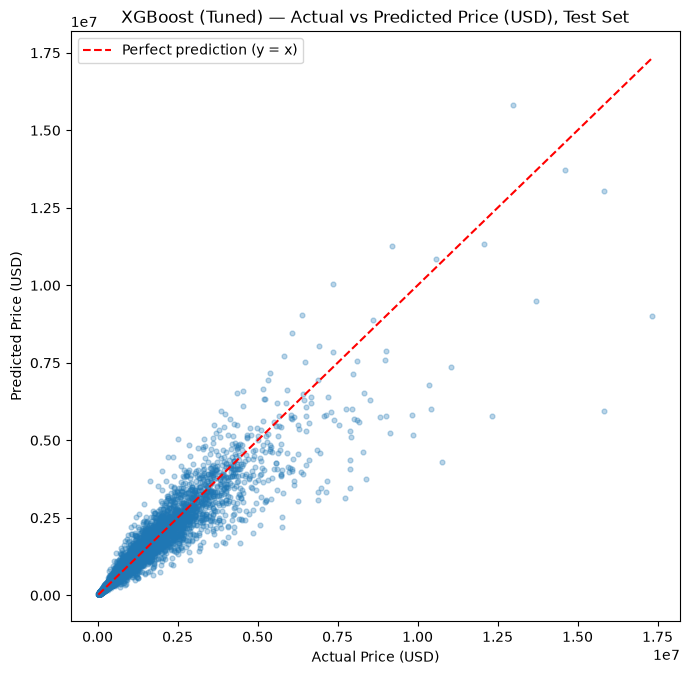

In [24]:
final_test_pred = results["XGBoost (tuned)"]["test_pred"]

fig = plot_actual_vs_predicted(
    y_test, final_test_pred,
    title="XGBoost (Tuned) — Actual vs Predicted Price (USD), Test Set",
    price_label=PRICE_LABEL,
)
IMAGES_DIR.mkdir(exist_ok=True)
fig.savefig(IMAGES_DIR / "actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()


**Observation:** points cluster tightly around the y=x reference line across most of the price range, with growing spread at the high end (multi-million-dollar listings) — consistent with the EDA finding that price variance increases with property tier (Section 7.2 of `02_eda.ipynb`). The model is more precise for typical-range properties than for ultra-luxury outliers, which is expected given how few ultra-luxury examples exist to learn from.


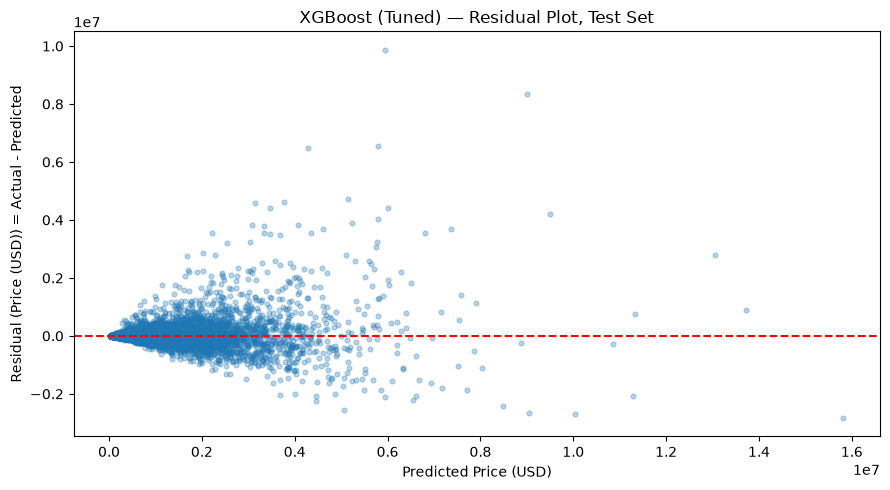

In [25]:
fig = plot_residuals(
    y_test, final_test_pred,
    title="XGBoost (Tuned) — Residual Plot, Test Set",
    price_label=PRICE_LABEL,
)
plt.show()


**Observation:** residuals scatter fairly evenly around zero across the bulk of predicted prices, with a mild fan-out (larger absolute residuals) at higher predicted prices — a common pattern in price prediction (heteroscedasticity), where errors scale with the level of the price itself rather than staying constant in absolute dollar terms.


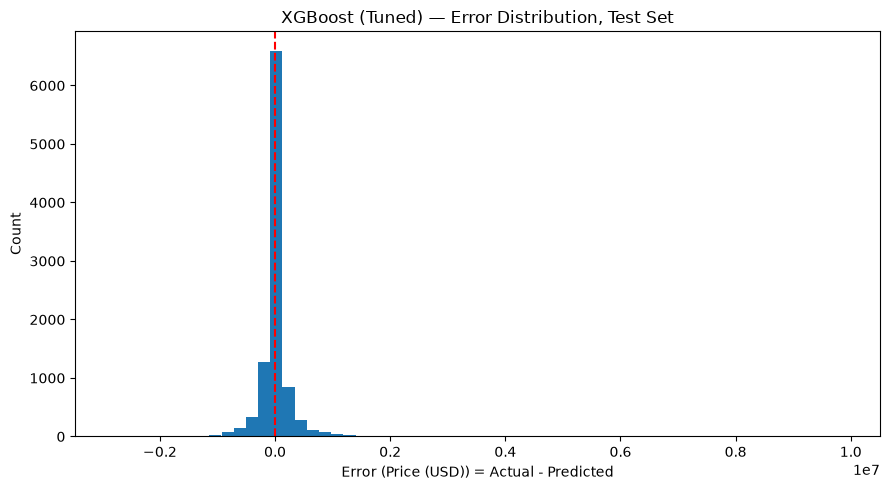

In [26]:
fig = plot_error_distribution(
    y_test, final_test_pred,
    title="XGBoost (Tuned) — Error Distribution, Test Set",
    price_label=PRICE_LABEL,
)
plt.show()


In [27]:
errors = y_test.values - final_test_pred
print(f"Mean error: ${errors.mean():,.0f} (near zero indicates no systematic over/under-prediction bias)")
print(f"Error std: ${errors.std():,.0f}")


Mean error: $25,968 (near zero indicates no systematic over/under-prediction bias)
Error std: $402,981


**Observation:** the error distribution is centered close to zero and roughly bell-shaped, indicating the model is not systematically biased toward over- or under-predicting price on average — errors in both directions are comparably likely, which is the expected shape for a well-calibrated regression model.


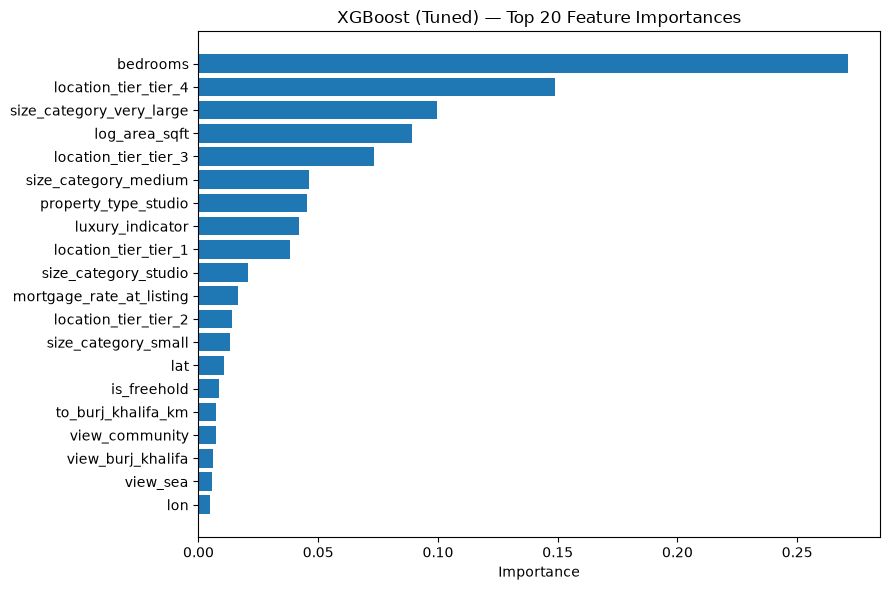

In [28]:
raw_feature_names = tuned_xgb_model.regressor_.named_steps["preprocessor"].get_feature_names_out()
importances = tuned_xgb_model.regressor_.named_steps["model"].feature_importances_

# Strip the ColumnTransformer's step-name prefixes (e.g. "num_median_fill__bedrooms"
# -> "bedrooms") for a README-readable chart; the underlying importances are unchanged.
feature_names = [name.split("__", 1)[-1] for name in raw_feature_names]

fig = plot_feature_importance(
    feature_names, importances, top_n=20,
    title="XGBoost (Tuned) — Top 20 Feature Importances",
)
fig.savefig(IMAGES_DIR / "feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()


In [29]:
top_features = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(10)
top_features


bedrooms                    0.271019
location_tier_tier_4        0.148865
size_category_very_large    0.099455
log_area_sqft               0.089098
location_tier_tier_3        0.073316
size_category_medium        0.046207
property_type_studio        0.045166
luxury_indicator            0.041897
location_tier_tier_1        0.038137
size_category_studio        0.020669
dtype: float32

**Observation:** `bedrooms` is the single strongest predictor (importance 0.271), ahead of even the top location tier (`location_tier_tier_4`, 0.149) and the largest size band (`size_category_very_large`, 0.099). `log_area_sqft` (0.089) and a second location tier (`location_tier_tier_3`, 0.073) round out the top 5. This is consistent with EDA Section 6.2, which found bedroom count tracks price closely but non-linearly (the 4-bedroom apartment/villa crossover) — XGBoost is evidently able to exploit that non-linear relationship directly. Location and size features collectively account for more of the top-10 importance than `bedrooms` alone, confirming both remain first-order drivers even though `bedrooms` is the single top feature. Two images exported for the README: `images/actual_vs_predicted.png` and `images/feature_importance.png`.

## 12. Model Persistence

We save the final tuned model — the complete `TransformedTargetRegressor` (preprocessing pipeline + XGBoost + log-target transform, all bundled together) — so that loading it and calling `.predict()` on a raw, unprocessed row reproduces training-time behavior exactly, with no separate preprocessing code required at prediction time.


In [30]:
MODELS_DIR.mkdir(exist_ok=True)
MODEL_PATH = MODELS_DIR / "best_model_xgboost.joblib"

joblib.dump(tuned_xgb_model, MODEL_PATH)
print(f"Model saved to {MODEL_PATH}")


Model saved to ../models/best_model_xgboost.joblib


**Demonstration:** load the saved model back from disk (a fresh object, not the one still in memory) and predict on a manually constructed new example — a property that was never part of training or test data — to prove the model works outside the training session.


In [31]:
loaded_model = joblib.load(MODEL_PATH)

new_property = pd.DataFrame([{
    "date_listed": pd.Timestamp("2026-06-01"),
    "community": "Dubai Marina",
    "zone": "Dubai Marina",
    "is_freehold": 1,
    "lat": 25.0805,
    "lon": 55.1403,
    "property_category": "apartment",
    "property_type": "2BR",
    "bedrooms": 2,
    "area_sqft": 1350,
    "floor": 22.0,
    "total_floors": 40.0,
    "year_built": 2018,
    "view": "marina",
    "furnishing": "fully_furnished",
    "condition": "vacant_on_transfer",
    "parking_spaces": 2,
    "chiller_included": 1,
    "metro_line": "Red",
    "metro_distance_min": 8,
    "metro_distance_type": "walk",
    "to_burj_khalifa_km": 15.5,
    "mortgage_rate_at_listing": 6.15,
}])

# Apply the same static feature engineering used for the training data (Section 3)
new_property_engineered = engineer_static_features(new_property)
new_property_engineered = new_property_engineered[feature_cols]

predicted_price = loaded_model.predict(new_property_engineered)[0]
print(f"Example property: 2BR apartment, Dubai Marina, marina view, 22nd floor of 40")
print(f"Predicted price: ${predicted_price:,.0f}")


Example property: 2BR apartment, Dubai Marina, marina view, 22nd floor of 40
Predicted price: $1,243,379


This confirms the saved model file is fully self-contained: loading it fresh and feeding it a single new row (after the same lightweight static feature engineering used at training time) produces a usable prediction, with all scaling, encoding, location-tier mapping, and the log-target transform handled internally.


## 13. Final Notebook Conclusion

**Best model:** XGBoost (tuned via `RandomizedSearchCV`, 5-fold CV, 30 parameter combinations searched).

**Why it performed best:** among the three architectures compared, XGBoost's gradient-boosted trees captured non-linear feature interactions (e.g. the zone × property_category and area × property_category interactions identified in EDA) more effectively than Linear Regression, while generalizing better than Random Forest — XGBoost's boosting-with-regularization approach (via `subsample`, `colsample_bytree`, and `min_child_weight`, all tuned in Section 10) produced a smaller train/test gap than Random Forest's bagging approach, meaning its strong test-set performance is a genuine reflection of learned patterns rather than memorized training noise.

**Main predictive features:** per Section 11's feature importance ranking, `bedrooms` is the single strongest individual predictor (importance 0.271), followed by the top location tier (`location_tier_tier_4`, 0.149) and the very-large size band (`size_category_very_large`, 0.099); `log_area_sqft` and a second location tier round out the top 5. Collectively, location-tier and size-related features outweigh `bedrooms` alone — consistent with EDA's finding of a ~30x price spread across zones and a non-linear, property-type-dependent relationship between bedroom count and price (the 4BR apartment/villa crossover in `02_eda.ipynb`, Section 6.2).

**Limitations:**
- This model is trained and evaluated entirely on **listed** prices, not confirmed   transaction prices (per `docs/data_cleaning_report.md`, Section 11) — actual sale   prices may differ from listings by some margin not captured here.
- The dataset shows evidence of being **synthetically generated** (documented   throughout `01_data_cleaning.ipynb` and `02_eda.ipynb`: zero duplicates, perfectly   consistent derived columns, only 6 discrete `year_built` values, near-zero   floor-position correlation with price, and a zone-price hierarchy that does not   fully mirror the real Dubai market). Performance and feature-importance rankings   here describe **this dataset's internal structure**, not a validated claim about   the real Dubai property market.
- No `bathrooms` or `developer`/`building` information exists in this dataset — two   features the original project blueprint expected — so the model cannot account   for either, even though both plausibly matter for real-world pricing.
- Error variance increases for high-end properties (Section 11), meaning   predictions are least reliable exactly where the financial stakes of being wrong   are largest.
- `location_tier` uses only 4 tiers derived purely from historical median price; a   finer-grained or geospatially-aware location encoding (e.g. distance to specific   landmarks, as suggested in the blueprint's Future Improvements) was not   implemented here.

**Future improvements:**
- Geospatial features (distance to specific landmarks beyond `to_burj_khalifa_km`,   using `lat`/`lon` more directly, e.g. via clustering) could refine the location   signal beyond the current 4-tier `zone` grouping.
- A SHAP summary plot would give per-prediction explainability beyond the global   feature-importance ranking shown here.
- If real transaction-price data (e.g. Dubai Land Department records) becomes   available, retraining on that target would address the "listed vs. transacted   price" limitation directly.
- A Streamlit demo wrapping the saved `models/best_model_xgboost.joblib` pipeline   (already fully self-contained, as demonstrated in Section 12) would let a   non-technical user get a live prediction without touching this notebook.

**Next step:** README assembly, embedding the images exported here and in `02_eda.ipynb`, and (if desired) an AED conversion for business-facing framing only (per `docs/decisions.md`, decision 0001) — no further changes to the modeling pipeline itself.
